## Predicting Floods in Sub-Saharan Africa Using Satellite Imagery and Computer Vision

# Project Objective

Developing a machine learning system that can predict floods 3 days in advance in Sub-Saharan Africa using Satellite imagery and related environmental data. The focus will be on demonstrating the application of computer vision techniques to extract spatial patterns predictive of flooding


# Motivation

- Floods are a major hazard in Sub-Saharan Africa, causing property damage, displacement, and loss of life.
- Early prediction enables disaster preparedness and humanitarian response.
- Satellite imagery is increasingly available, offering a rich visual dataset for flood prediction.
- This project demonstrates the use of computer vision pipelines in a real-world social-impact context.


In [2]:
# Load necessary libraries

# Core
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import geemap

# Geospatial + raster
import rasterio
from rasterio.plot import show
import geopandas as gpd
import ee
# ml4floods not installed in this env 
# from ml4floods import ...
# from ml4floods.data import worldfloods
# georeader not installed in this env 
# from georeader import window_utils
from shapely.geometry import box


# Notebook display
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Local fallback for band ordering (used by Dataset)
BANDS_S2 = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B10','B11','B12']

print("Imports loaded.")


Imports loaded.


In [3]:
# Load dataset

DATA_ROOT = Path("/Volumes/Munashe/WorldFloodsv2")

print("DATA_ROOT:", DATA_ROOT)
print("Contents:", [p.name for p in DATA_ROOT.iterdir()])

DATA_ROOT: /Volumes/Munashe/WorldFloodsv2
Contents: ['.cache', 'test', 'README.md', '.gitattributes', 'dataset_metadata.csv', 'train', '._README.md', '.Rhistory', '._.Rhistory', '._dataset_metadata.csv']


In [ ]:
# Visualize a sample S2 image



## Standard U-Net

The Architecture: Vanilla U-Net
- Backbone: ResNet-18 or ResNet-34 encoder as it is light to train on my resource constrained computer
- Loss Function: Dice Loss or combination of Binary Cross Entropy + Dice to handle the class imbalance since most of the image is land and a small part is flood

In [28]:
# ResNet-backed U-Net (lightweight; supports resnet18 or resnet34 encoder)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


class ConvRelu(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        # Upsample then convs after concatenation with skip
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv1 = ConvRelu(in_ch + skip_ch, out_ch)
        self.conv2 = ConvRelu(out_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # If necessary, pad to match skip size
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class UNetResNet(nn.Module):
    """
    U-Net with a ResNet encoder (choose depth=18 or 34). Outputs logits (no sigmoid) for use with BCEWithLogitsLoss.
    """
    def __init__(self, encoder='resnet18', pretrained=False, out_channels=1, n_input_channels=3):
        super().__init__()
        assert encoder in ('resnet18', 'resnet34')
        if encoder == 'resnet18':
            resnet = models.resnet18(pretrained=pretrained)
            filters = [64, 64, 128, 256, 512]
        else:
            resnet = models.resnet34(pretrained=pretrained)
            filters = [64, 64, 128, 256, 512]

        # Adapt first conv if input channels != 3
        if n_input_channels != 3:
            old_conv = resnet.conv1
            resnet.conv1 = nn.Conv2d(n_input_channels, old_conv.out_channels,
                                     kernel_size=old_conv.kernel_size,
                                     stride=old_conv.stride,
                                     padding=old_conv.padding,
                                     bias=old_conv.bias)

        # Encoder (take sequential layers from ResNet)
        self.initial = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # produces 64 ch
        self.pool = resnet.maxpool
        self.encoder1 = resnet.layer1  # 64
        self.encoder2 = resnet.layer2  # 128
        self.encoder3 = resnet.layer3  # 256
        self.encoder4 = resnet.layer4  # 512

        # Center / bridge
        self.center = nn.Sequential(
            ConvRelu(filters[4], filters[4]),
            ConvRelu(filters[4], filters[4])
        )

        # Decoder blocks (match channels to encoder skip connections)
        self.dec4 = DecoderBlock(filters[4], filters[3], filters[3])  # 512 -> +256 -> 256
        self.dec3 = DecoderBlock(filters[3], filters[2], filters[2])  # 256 -> +128 -> 128
        self.dec2 = DecoderBlock(filters[2], filters[1], filters[1])  # 128 -> +64 -> 64
        self.dec1 = DecoderBlock(filters[1], filters[0], filters[0])  # 64 -> +64 -> 64

        # Final conv to output desired channels
        self.final_conv = nn.Sequential(
            ConvRelu(filters[0], filters[0] // 2),
            nn.Conv2d(filters[0] // 2, out_channels, kernel_size=1)
        )

    def forward(self, x):
        # Encoder
        x0 = self.initial(x)      # after conv1: 64 ch, spatial /2
        x1 = self.pool(x0)        # /4
        e1 = self.encoder1(x1)    # 64
        e2 = self.encoder2(e1)    # 128
        e3 = self.encoder3(e2)    # 256
        e4 = self.encoder4(e3)    # 512

        # Center
        c = self.center(e4)

        # Decoder (upsample + skip connections)
        d4 = self.dec4(c, e3)
        d3 = self.dec3(d4, e2)
        d2 = self.dec2(d3, e1)
        d1 = self.dec1(d2, x0)

        out = self.final_conv(d1)
        # returns logits; apply sigmoid in training/inference as needed
        return out

In [29]:
# Dataset, DataLoader, training and evaluation for S2 to GT flood masks
import random
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import torch.nn.functional as F  # needed for interpolation/resizing

# Geospatial reprojection utils
from rasterio.warp import reproject
from rasterio.enums import Resampling

# using local BANDS_S2 defined in the imports cell above instead of importing from ml4floods

# ---- WorldFloods GT structure (as observed in your files) ----
# GT is a 2-band raster:
#   Band 1 (channel 0): Quality / cloud mask
#       0 = no data / invalid
#       1 = clear
#       2 = cloud
#   Band 2 (channel 1): Land cover
#       0 = no data
#       1 = land (dry)
#       2 = water (total water = permanent + flood)
#
# Target definition:
#   - water pixels are landcover == 2
# Validity definition (for loss/metrics masking):
#   - quality == 1 (clear)
#   - and landcover != 0 (not nodata)
LANDCOVER_WATER = 2
QUALITY_CLEAR = 1


class WorldFloodsTilesDataset(Dataset):
    """Reads S2 tiles and aligned GT masks.

    Returns:
      - img_t: (C,H,W) float32
      - mask_t: (1,H,W) float32 in {0,1} where 1 indicates water (total water)
      - valid_t: (1,H,W) float32 in {0,1} where 1 indicates pixels to include in loss/metrics

    Args:
      - bands: list of band names, e.g. ['B4','B3','B8']
      - max_samples: optional cap for quick tests
      - transforms: callable(img, mask, valid) -> (img, mask, valid) operating on numpy
      - target_size: (H, W) tuple to resize all samples to a fixed spatial size (optional)
    """

    def __init__(
        self,
        data_root,
        split='train',
        bands=('B4', 'B3', 'B8'),
        max_samples=None,
        transforms=None,
        scale=3500.0,
        target_size=None,
    ):
        self.data_root = Path(data_root)
        self.s2_dir = self.data_root / split / 'S2'
        self.gt_dir = self.data_root / split / 'gt'
        self.transforms = transforms
        self.scale = float(scale)
        self.band_names = list(bands)
        # map band names to 1-based rasterio indexes using local BANDS_S2
        self.band_idxs = [BANDS_S2.index(b) + 1 for b in self.band_names]
        self.target_size = tuple(target_size) if target_size is not None else None

        s2_files = sorted(self.s2_dir.glob('*.tif')) if self.s2_dir.exists() else []
        pairs = []
        for s in s2_files:
            candidate_gt = self.gt_dir / f"{s.stem}.tif"
            if candidate_gt.exists():
                pairs.append((s, candidate_gt))
            else:
                prefix = s.stem.split('_')[0]
                cand = sorted(self.gt_dir.glob(f"{prefix}*.tif")) if self.gt_dir.exists() else []
                if cand:
                    pairs.append((s, cand[0]))

        if max_samples is not None:
            pairs = pairs[:max_samples]
        if not pairs:
            raise RuntimeError(f'No S2/GT pairs found in {self.s2_dir} / {self.gt_dir}')
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def _read_gt(self, gt_path):
        """Read GT quality + landcover bands.

        Returns:
          quality: (H,W) int32
          landcover: (H,W) int32
          meta: dict with transform/crs/nodata/shape
        """
        with rasterio.open(gt_path) as src_gt:
            if src_gt.count < 2:
                raise RuntimeError(
                    f"Expected 2-band GT (quality+landcover) but got {src_gt.count} bands: {gt_path}"
                )
            quality = src_gt.read(1).astype('int32')
            landcover = src_gt.read(2).astype('int32')
            meta = {
                'transform': src_gt.transform,
                'crs': src_gt.crs,
                'nodata': src_gt.nodata,
                'shape': (src_gt.height, src_gt.width),
            }
        return quality, landcover, meta

    def _align_gt_band(self, band_arr, src_transform, src_crs, dst_shape, dst_transform, dst_crs, fill_value=0):
        """Reproject a single-band integer raster onto the S2 grid."""
        dst = np.full(dst_shape, fill_value, dtype=band_arr.dtype)
        reproject(
            source=band_arr,
            destination=dst,
            src_transform=src_transform,
            src_crs=src_crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest,
        )
        return dst

    def __getitem__(self, idx):
        s2_path, gt_path = self.pairs[idx]

        with rasterio.open(s2_path) as src_s2:
            # Read selected bands
            bands = [src_s2.read(i).astype('float32') for i in self.band_idxs]
            s2_crs = src_s2.crs
            s2_transform = src_s2.transform
            height, width = src_s2.height, src_s2.width

        # Stack and scale to [0,1] like reflectance
        img = np.stack(bands, axis=0) / self.scale  # shape (C,H,W)

        # Read GT two-band structure
        quality, landcover, gt_meta = self._read_gt(gt_path)

        # Align BOTH quality and landcover to S2 grid if needed
        if gt_meta['shape'] != (height, width) or gt_meta['crs'] != s2_crs:
            quality = self._align_gt_band(
                quality,
                src_transform=gt_meta['transform'],
                src_crs=gt_meta['crs'],
                dst_shape=(height, width),
                dst_transform=s2_transform,
                dst_crs=s2_crs,
                fill_value=0,
            )
            landcover = self._align_gt_band(
                landcover,
                src_transform=gt_meta['transform'],
                src_crs=gt_meta['crs'],
                dst_shape=(height, width),
                dst_transform=s2_transform,
                dst_crs=s2_crs,
                fill_value=0,
            )

        # Binary water mask from landcover
        gt_mask = (landcover == LANDCOVER_WATER).astype('uint8')  # 1=water

        # Valid pixels for loss/metrics: clear + landcover not nodata
        valid = ((quality == QUALITY_CLEAR) & (landcover != 0)).astype('uint8')

        # Optional simple augmentations (operate on numpy arrays)
        if self.transforms is not None:
            # Support both legacy (img, mask) and (img, mask, valid)
            try:
                img, gt_mask, valid = self.transforms(img, gt_mask, valid)
            except TypeError:
                img, gt_mask = self.transforms(img, gt_mask)

        # Convert to torch tensors
        img_t = torch.from_numpy(img).float()
        mask_t = torch.from_numpy(gt_mask).unsqueeze(0).float()   # (1,H,W)
        valid_t = torch.from_numpy(valid).unsqueeze(0).float()    # (1,H,W)

        # If requested, resize to target_size using torch's interpolate
        if self.target_size is not None:
            H, W = self.target_size
            img_t = F.interpolate(img_t.unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False).squeeze(0)
            # mask/valid use nearest interpolation
            mask_t = F.interpolate(mask_t.unsqueeze(0), size=(H, W), mode='nearest').squeeze(0)
            valid_t = F.interpolate(valid_t.unsqueeze(0), size=(H, W), mode='nearest').squeeze(0)

        return img_t, mask_t, valid_t


# Simple deterministic transforms (random flips)
def simple_transforms(img, mask, valid=None, p_flip=0.5):
    # img: numpy (C,H,W), mask: (H,W), valid: (H,W) or None
    if random.random() < p_flip:
        # horizontal
        img = img[:, :, ::-1].copy()
        mask = mask[:, ::-1].copy()
        if valid is not None:
            valid = valid[:, ::-1].copy()
    if random.random() < p_flip:
        # vertical
        img = img[:, ::-1, :].copy()
        mask = mask[::-1, :].copy()
        if valid is not None:
            valid = valid[::-1, :].copy()

    if valid is None:
        return img, mask
    return img, mask, valid


In [30]:
# Load dataset

DATA_ROOT = Path("/Volumes/Munashe/WorldFloodsv2")

print("DATA_ROOT:", DATA_ROOT)
print("Contents:", [p.name for p in DATA_ROOT.iterdir()])

DATA_ROOT: /Volumes/Munashe/WorldFloodsv2
Contents: ['.cache', 'test', 'README.md', '.gitattributes', 'dataset_metadata.csv', 'train', '._README.md', '.Rhistory', '._.Rhistory', '._dataset_metadata.csv']


In [31]:
# Quick sanity-check: what labels exist in GT (2-band: quality + landcover)?

# This cell is intentionally independent of `full_ds` so it can run before the dataset is built.
GT_DIR = DATA_ROOT / 'test' / 'gt'

gt_files = sorted(GT_DIR.glob('*.tif'))
if not gt_files:
    raise RuntimeError(f"No GT files found in: {GT_DIR}")

# Look at a few GT files and print unique label values for BOTH bands
for i, gt_path in enumerate(gt_files[:3]):
    with rasterio.open(gt_path) as src:
        if src.count < 2:
            raise RuntimeError(f"Expected 2-band GT but got {src.count} band(s): {gt_path}")
        quality = src.read(1)
        landcover = src.read(2)

    q_uniq, q_counts = np.unique(quality, return_counts=True)
    l_uniq, l_counts = np.unique(landcover, return_counts=True)

    print(f"{i}: {gt_path.name}")
    print("  quality unique:", dict(zip(q_uniq.tolist(), q_counts.tolist())))
    print("  landcover unique:", dict(zip(l_uniq.tolist(), l_counts.tolist())))


0: EMSR264_08VATOMANDRY_DEL_v2.tif
  quality unique: {0: 459697, 1: 12642870, 2: 6320252}
  landcover unique: {0: 5104326, 1: 7382063, 2: 6936430}
1: EMSR264_18MIANDRIVAZODETAIL_DEL_v2.tif
  quality unique: {0: 9115, 1: 1870161, 2: 129614}
  landcover unique: {0: 138729, 1: 1573471, 2: 296690}
2: EMSR273_01GRILE_DEL_MONIT04_v2.tif
  quality unique: {0: 26253, 1: 763044}
  landcover unique: {0: 26253, 1: 477506, 2: 285538}


In [32]:
# Build dataset from the test split only (S2/GT pairs exist only in test for now)
# Use a fixed target_size so all samples have the same spatial dimensions and collate won't fail
full_ds = WorldFloodsTilesDataset(
    DATA_ROOT,
    split='test',
    bands=('B4', 'B3', 'B8'),
    max_samples=None,
    transforms=simple_transforms,
    target_size=(512, 512),
)

# Deterministic train/val split from the available test pairs
from torch.utils.data import random_split

total = len(full_ds)
if total < 2:
    raise RuntimeError(f'Not enough samples in test split to create train/val sets (found {total})')

val_frac = 0.2
val_size = max(1, int(total * val_frac))
train_size = total - val_size

# Use a fixed seed for reproducibility
generator = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(full_ds, [train_size, val_size], generator=generator)

# DataLoaders (small batch size for laptop)
batch_size = 2  # reduced to lower memory usage
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

print('Total samples (from test/):', total)
print('Train samples:', len(train_ds), 'Val samples:', len(val_ds))


# Training utilities: masked BCE + masked dice, masked metrics

def masked_bce_with_logits(logits, targets, valid, eps=1e-6):
    """BCE over valid pixels only.

    logits/targets/valid: (B,1,H,W)
    valid is expected to be 0/1.
    """
    loss_map = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    valid = (valid > 0).float()
    denom = valid.sum().clamp_min(eps)
    return (loss_map * valid).sum() / denom


def masked_dice_loss_logits(logits, targets, valid, eps=1e-6):
    """Soft dice over valid pixels only."""
    probs = torch.sigmoid(logits)
    valid = (valid > 0).float()

    probs = probs * valid
    targets = targets * valid

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1.0 - dice.mean()


def threshold_predictions(logits, thresh=0.5):
    return (torch.sigmoid(logits) >= thresh).to(torch.uint8)


def masked_binary_metrics(preds, targets, valid, eps=1e-6):
    """IoU/precision/recall computed over valid pixels only.

    preds/targets/valid: numpy arrays in shape (H,W) with {0,1}
    """
    v = valid.astype(bool).ravel()
    if v.sum() == 0:
        return np.nan, np.nan, np.nan

    y_pred = preds.ravel()[v]
    y_true = targets.ravel()[v]

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    prec = tp / (tp + fp + eps)
    rec = tp / (tp + fn + eps)

    inter = tp
    union = int(((y_true == 1) | (y_pred == 1)).sum())
    iou = inter / (union + eps)
    return iou, prec, rec


Total samples (from test/): 18
Train samples: 15 Val samples: 3


In [33]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Build model
model = UNetResNet(encoder='resnet18', pretrained=False, out_channels=1, n_input_channels=3)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


def _unpack_batch(batch):
    """Support (imgs, masks) and (imgs, masks, valid) batches."""
    if isinstance(batch, (list, tuple)) and len(batch) == 2:
        imgs, masks = batch
        valid = None
        return imgs, masks, valid
    if isinstance(batch, (list, tuple)) and len(batch) == 3:
        imgs, masks, valid = batch
        return imgs, masks, valid
    raise ValueError(
        f"Unexpected batch structure: type={type(batch)} len={len(batch) if isinstance(batch, (list, tuple)) else 'n/a'}"
    )


def _ensure_valid(valid, like_tensor):
    """If a dataset doesn't provide valid, treat all pixels as valid."""
    if valid is None:
        return torch.ones_like(like_tensor)
    return valid


# Small training loop
num_epochs = 3
for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0

    for batch in train_loader:
        imgs, masks, valid = _unpack_batch(batch)
        imgs = imgs.to(device)
        masks = masks.to(device)
        valid = _ensure_valid(valid, masks).to(device)

        optimizer.zero_grad()
        logits = model(imgs)

        # Resize logits to match GT spatial size before computing losses/metrics
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

        loss_bce = masked_bce_with_logits(logits, masks, valid)
        loss_dice = masked_dice_loss_logits(logits, masks, valid)
        loss = loss_bce + loss_dice

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    epoch_loss = running_loss / len(train_ds)

    # Validation (masked metrics)
    model.eval()
    iou_list = []
    prec_list = []
    rec_list = []

    with torch.no_grad():
        for batch in val_loader:
            imgs, masks, valid = _unpack_batch(batch)
            imgs = imgs.to(device)
            masks = masks.to(device)
            valid = _ensure_valid(valid, masks).to(device)

            logits = model(imgs)
            if logits.shape[-2:] != masks.shape[-2:]:
                logits = F.interpolate(logits, size=masks.shape[-2:], mode='bilinear', align_corners=False)

            preds = threshold_predictions(logits, thresh=0.5).float()

            preds_np = preds.cpu().numpy().astype(np.uint8)
            masks_np = masks.cpu().numpy().astype(np.uint8)
            valid_np = valid.cpu().numpy().astype(np.uint8)

            for i in range(preds_np.shape[0]):
                iou, prec, rec = masked_binary_metrics(
                    preds_np[i, 0],
                    masks_np[i, 0],
                    valid_np[i, 0],
                )
                if not np.isnan(iou):
                    iou_list.append(iou)
                if not np.isnan(prec):
                    prec_list.append(prec)
                if not np.isnan(rec):
                    rec_list.append(rec)

    mean_iou = float(np.mean(iou_list)) if iou_list else float('nan')
    mean_prec = float(np.mean(prec_list)) if prec_list else float('nan')
    mean_rec = float(np.mean(rec_list)) if rec_list else float('nan')

    print(
        f'Epoch {epoch}/{num_epochs} | train_loss={epoch_loss:.4f} | '
        f'val IoU={mean_iou:.4f} | prec={mean_prec:.4f} | rec={mean_rec:.4f}'
    )

# Save a checkpoint
ckpt_path = Path('unet_resnet18_checkpoint.pth')
torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, ckpt_path)
print('Saved checkpoint to', ckpt_path)


Using device: cpu
Epoch 1/3 | train_loss=1.1884 | val IoU=0.0335 | prec=0.3740 | rec=0.0345
Epoch 1/3 | train_loss=1.1884 | val IoU=0.0335 | prec=0.3740 | rec=0.0345
Epoch 2/3 | train_loss=0.9725 | val IoU=0.0005 | prec=0.2178 | rec=0.0005
Epoch 2/3 | train_loss=0.9725 | val IoU=0.0005 | prec=0.2178 | rec=0.0005
Epoch 3/3 | train_loss=0.9522 | val IoU=0.0082 | prec=0.6100 | rec=0.0082
Epoch 3/3 | train_loss=0.9522 | val IoU=0.0082 | prec=0.6100 | rec=0.0082
Saved checkpoint to unet_resnet18_checkpoint.pth
Saved checkpoint to unet_resnet18_checkpoint.pth


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.0335867].


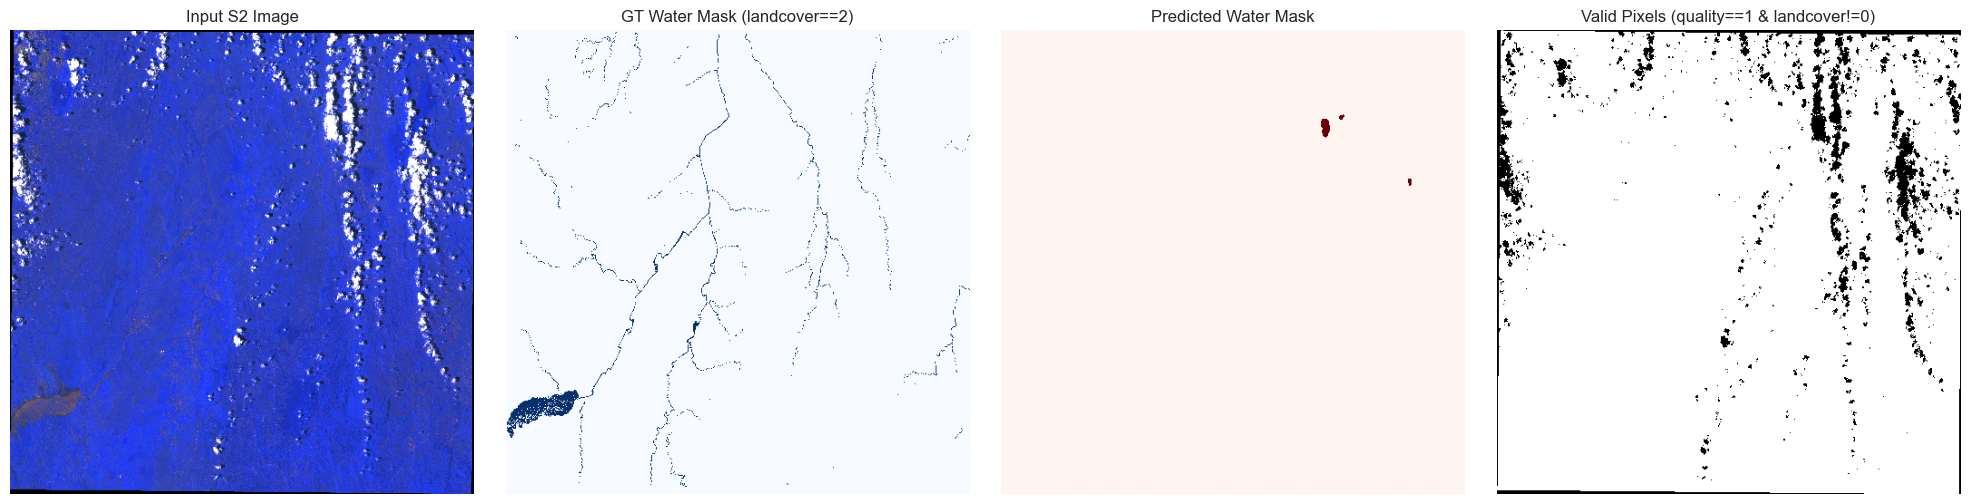

In [34]:
# View sample image, GT mask, and prediction

def visualize_sample(model, dataset, idx=0, device='cpu', show_valid=True):
    model.eval()
    item = dataset[idx]
    if isinstance(item, (list, tuple)) and len(item) == 3:
        img_t, mask_t, valid_t = item
    else:
        img_t, mask_t = item
        valid_t = None

    img = img_t.numpy().transpose(1, 2, 0)  # (H,W,C)
    gt_mask = mask_t.squeeze(0).numpy()     # (H,W)
    valid_mask = valid_t.squeeze(0).numpy() if valid_t is not None else None

    with torch.no_grad():
        input_t = img_t.unsqueeze(0).to(device)  # (1,C,H,W)
        logits = model(input_t)
        if logits.shape[-2:] != mask_t.shape[-2:]:
            logits = F.interpolate(logits, size=mask_t.shape[-2:], mode='bilinear', align_corners=False)
        pred_mask = threshold_predictions(logits.cpu(), thresh=0.5).squeeze(0).squeeze(0).numpy()  # (H,W)

    ncols = 4 if (show_valid and valid_mask is not None) else 3
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5))
    if ncols == 3:
        ax0, ax1, ax2 = axes
    else:
        ax0, ax1, ax2, ax3 = axes

    ax0.imshow(img)
    ax0.set_title('Input S2 Image')
    ax0.axis('off')

    ax1.imshow(gt_mask, cmap='Blues')
    ax1.set_title('GT Water Mask (landcover==2)')
    ax1.axis('off')

    ax2.imshow(pred_mask, cmap='Reds')
    ax2.set_title('Predicted Water Mask')
    ax2.axis('off')

    if ncols == 4:
        ax3.imshow(valid_mask, cmap='gray')
        ax3.set_title('Valid Pixels (quality==1 & landcover!=0)')
        ax3.axis('off')

    plt.tight_layout()
    plt.show()


# Visualize a sample from the validation set
visualize_sample(model, val_ds, idx=0, device=device)


## Failure Analysis and Challenges

- Data & input differences vs. standard RGB CV:
  - Multispectral S2 tiles require band-selection, scaling and reprojection; inputs vary in resolution and CRS unlike fixed-size RGB photos.
  - Images are very large and spatially heterogeneous which increases memory and preprocessing complexity compared to typical RGB datasets.

- What breaks for this baseline and why:
  - Varying tile sizes caused batch collation failures until I forced a fixed target size.
  - Encoder downsampling produced logits at lower resolution; mismatch with mask resolution caused loss/metric errors until upsampling.
  - Small water bodies and fragmented flood pixels are easily lost by aggressive downsampling and interpolation.
  - Label noise and coarse GT (mixed classes, per-pixel misalignments) degrade supervised learning.

- Failure patterns observed / likely causes:
  - Class imbalance: flooded pixels are a small fraction → models bias toward background.
  - Small-instance sensitivity: thin rivers/ponds are missed due to limited receptive-field or resolution loss.
  - Domain shift & temporal misalignment: S2 sensing conditions and GT timing differ across events, hurting generalization.
  - Noisy or coarse annotations produce lower apparent IoU even when visual predictions are reasonable.

- Concise remediation recommendations:
  - Use of full training set and stronger augmentation (multi-scale, color/reflectance noise, temporal augmentation).
  - Training with class-balanced losses (focal / dice / weighted BCE) and sampling strategies to address imbalance.
  - Preservation of higher spatial detail: higher target_size or decoder upsampling, multi-scale supervision, and CRF/postprocessing.
  - Explore temporal models or ensembles and domain-adaptive pretraining (multispectral pretrained encoder).
